# Algoritma Machine Learning untuk Klasifikasi Spoiler pada Review Buku di platform Goodreads

Dataset ini digunakan untuk melatih dan mengevaluasi model Machine Learning dalam mendeteksi spoiler pada review buku Goodreads berbahasa Indonesia.

**Input:**
review_preprocessed.csv

File ini merupakan hasil preprocessing yang telah melalui tahap pembersihan dan normalisasi teks.

Kolom yang digunakan:
- review_text_stem
Teks yang telah melalui stopword removal dan stemming, digunakan sebagai fitur untuk model Machine Learning.
- spoiler_label
Label biner: 1 untuk spoiler, 0 untuk non-spoiler.

**Output:**
model_evaluation_results

Hasil berupa performa model klasifikasi yang mencakup metrik evaluasi serta perbandingan antar model.
Model yang digunakan:
- Support Vector Machine (SVM) dengan kernel linear
- Random Forest
- XGBoost

Langkah-langkah:
1. Setup Environment
2. Load Data
3. TF-IDF Vectorization
4. Train-Test Split
5. Setup Fungsi Evaluasi Model
6. Training & Evaluasi Model (SVM, Random Forest, XGBoost)
7. Perbandingan Model
8. Kesimpulan dan Analisis

## 1. Instalasi Dependensi

PERUBAHAN: imbalanced-learn dihapus dari daftar install karena SMOTE tidak jadi dipakai.
Karena data masuk sebagai TF-IDF sparse matrix, dan interpolasi vektor di ruang sparse tidak menghasilkan representasi teks yang bermakna secara linguistik. Sebagai gantinya, handling imbalance dilakukan lewat class_weight dan scale_pos_weight yang bekerja langsung pada fungsi loss tanpa mengubah distribusi data.

In [3]:
# install semua library yang dibutuhkan
# scikit-learn: library utama ML, sudah include SVM, Random Forest, Pipeline, dan GridSearchCV
# xgboost: implementasi gradient boosting yang dioptimasi
# pandas, numpy: manipulasi dan operasi data numerik
# matplotlib, seaborn: untuk visualisasi grafik

!pip install scikit-learn xgboost pandas numpy matplotlib seaborn

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 2.4 MB/s eta 0:00:43
   ---------------------------------------- 1.0/101.7 MB 1.7 MB/s eta 0:00:58
    --------------------------------------- 1.3/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 1.6/101.7 MB 1.6 MB/s eta 0:01:04
    --------------------------------------- 1.8/101.7 MB 1.6 MB/s eta 0:01:02
    --------------------------------------- 2.1/101.7 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 2.4/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 2.4/101.7 MB 1.5 MB/s eta 0:01:08
    ------------------

## 2. Import Library & Konfigurasi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings # untuk menyembunyikan pesan peringatan yang tidak penting
import time # untuk mengukur berapa lama proses berjalan

from sklearn.feature_extraction.text import TfidfVectorizer # untuk mengubah teks menjadi angka
from sklearn.pipeline import Pipeline # untuk menggabungkan TF-IDF + model
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold # untuk membagi data dan mencari hyperparameter terbaik

# import model-model machine learning yang akan digunakan
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,    # laporan lengkap precision, recall, f1 per kelas
    confusion_matrix,         # tabel perbandingan prediksi vs aktual
    roc_auc_score,            # skor AUC-ROC, metrik utama
    precision_score,          # dari semua yang diprediksi positif, berapa yang benar
    recall_score,             # dari semua yang benar positif, berapa yang berhasil terdeteksi
    f1_score,                 # rata-rata harmonis antara precision dan recall
    ConfusionMatrixDisplay    # untuk menampilkan confusion matrix dalam bentuk visual
)
from xgboost import XGBClassifier

# from google.colab import drive
# 
# drive.mount('/content/drive')

warnings.filterwarnings("ignore")

# konfigurasi path
# INPUT_CSV = '/content/drive/MyDrive/NLP_Kelompok3/review_preprocessed.csv'
INPUT_CSV = 'review_preprocessed.csv'
df = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')

# konstanta global
RANDOM_SEED = 42  # seed untuk reproducibility
TEST_SIZE   = 0.2 # 80% train, 20% test

## 3. Load & Eksplorasi Data

In [5]:
# load data hasil preprocessing
# encoding='utf-8-sig' menangani karakter BOM yang kadang muncul di file Windows
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

# tampilkan informasi dasar tentang dataset
print(f"total baris : {len(df)}")
print(f"total kolom : {len(df.columns)}")
print(f"kolom       : {list(df.columns)}")

# cek missing value pada kolom yang akan dipakai
print("\n missing values pada kolom yang dipakai")
print(df[["review_text_stem", "spoiler_label"]].isnull().sum())

# hapus baris yang kolom utamanya kosong
# reset_index(drop=True) biar index kembali rapi dari 0
df = df.dropna(subset=["review_text_stem", "spoiler_label"]).reset_index(drop=True)
print(f"\n setelah drop missing: {len(df)} baris")

total baris : 11267
total kolom : 3
kolom       : ['review_text_clean', 'review_text_stem', 'spoiler_label']

 missing values pada kolom yang dipakai
review_text_stem    0
spoiler_label       0
dtype: int64

 setelah drop missing: 11267 baris


In [6]:
# distribusi label dan perhitungan imbalance ratio (berapa review spoiler vs non-spoiler)
label_counts = df["spoiler_label"].value_counts()
label_pct    = df["spoiler_label"].value_counts(normalize=True) * 100

print("distribusi label")
# gabungkan jumlah dan persentase ke satu tabel yang mudah dibaca
dist_df = pd.DataFrame({
  "jumlah" : label_counts,
  "persen" : label_pct.round(2)
}).rename(index={0: "non-spoiler (0)", 1: "spoiler (1)"})
print(dist_df)

# hitung imbalance ratio, seberapa jauh ketimpangan antara dua kelas
n_nonspoiler = label_counts[0]
n_spoiler    = label_counts[1]
imbalance_ratio = n_nonspoiler / n_spoiler # angka ini nanti dipakai di XGBoost

print(f"\nimbalance ratio (non-spoiler / spoiler) : {imbalance_ratio:.2f}")
print(f"artinya: untuk setiap 1 spoiler, ada {imbalance_ratio:.1f} non-spoiler")

distribusi label
                 jumlah  persen
spoiler_label                  
non-spoiler (0)   10281   91.25
spoiler (1)         986    8.75

imbalance ratio (non-spoiler / spoiler) : 10.43
artinya: untuk setiap 1 spoiler, ada 10.4 non-spoiler


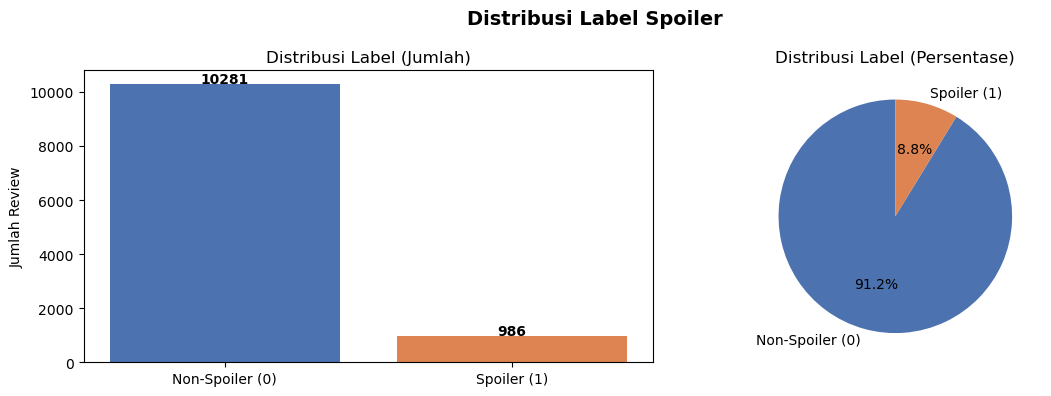

In [7]:
# visualisasi distribusi label (bar chart dan pie chart)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# biru untuk non-spoiler, oranye untuk spoiler
colors = ["#4C72B0", "#DD8452"]

# grafik kiri, bar chart jumlah absolut
axes[0].bar(["Non-Spoiler (0)", "Spoiler (1)"], [n_nonspoiler, n_spoiler], color=colors)
axes[0].set_title("Distribusi Label (Jumlah)")
axes[0].set_ylabel("Jumlah Review")
# tambahkan angka di atas masing-masing bar agar lebih mudah dibaca
for i, v in enumerate([n_nonspoiler, n_spoiler]):
  axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# grafik kanan, pie chart persentase
axes[1].pie(
  [n_nonspoiler, n_spoiler],
  labels=["Non-Spoiler (0)", "Spoiler (1)"],
  autopct="%1.1f%%",
  colors=colors,
  startangle=90
)
axes[1].set_title("Distribusi Label (Persentase)")

plt.suptitle("Distribusi Label Spoiler", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("distribusi_label.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# hitung panjang teks (dalam jumlah kata/token) per review
# panjang teks bisa jadi sinyal, spoiler mungkin cenderung lebih panjang
df["text_len"] = df["review_text_stem"].apply(lambda x: len(str(x).split()))

# tampilkan statistik deskriptif panjang teks, dikelompokkan berdasarkan label
print("statistik panjang teks (jumlah token) per label")
print(df.groupby("spoiler_label")["text_len"].describe().round(2).rename(index={0: "non-spoiler", 1: "spoiler"}))

statistik panjang teks (jumlah token) per label
                 count   mean    std  min   25%   50%    75%     max
spoiler_label                                                       
non-spoiler    10281.0  63.05  70.06  1.0  18.0  39.0   83.0  1149.0
spoiler          986.0  85.16  93.81  2.0  30.0  60.0  115.0  1162.0


## 3. Persiapan Data & Train-Test Split

PERUBAHAN: Di versi lama, TF-IDF di-fit di sini sebelum GridSearchCV berjalan

```python
# VERSI LAMA ada data leakage
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2), ...)
X_train = vectorizer.fit_transform(X_train_raw)   # vocabulary sudah "lihat" semua train data
X_test  = vectorizer.transform(X_test_raw)
```

Masalahnya ketika GridSearchCV membagi train set menjadi 5 fold, vocabulary TF-IDF sudah terbentuk dari semua train data termasuk fold yang seharusnya jadi validasi. Ini disebut data leakage, jadi model secara tidak langsung sudah "melihat" distribusi kata di fold validasi sebelum dievaluasi di sana.

Solusinya adalah Pipeline, jadi TF-IDF dan model digabung jadi satu objek. Ketika GridSearchCV berjalan, Pipeline secara otomatis men-fit TF-IDF hanya di fold training dan men-transform fold validasi, persis seperti yang seharusnya.

Stratified Split karena split biasa tidak menjamin proporsi label yang sama di train dan test set. Dengan imbalance 10.58:1, bisa saja test set berisi terlalu sedikit spoiler secara kebetulan dan membuat evaluasi tidak representatif. Stratified split memastikan proporsi terjaga.

In [9]:
# persiapan data
# X (fitur/input) dan y (label/target)
# .astype(str) memastikan tidak ada tipe data campuran yang bisa menyebabkan error
# X berisi raw text, bukan matriks TF-IDF
# TF-IDF sekarang ada di dalam Pipeline setiap model
X = df["review_text_stem"].astype(str).tolist()
y = df["spoiler_label"].astype(int)

print(f"jumlah sampel: {len(X)}")
print(f"distribusi y: {dict(y.value_counts().sort_index())}")

jumlah sampel: 11267
distribusi y: {0: 10281, 1: 986}


In [10]:
# bagi data menjadi training set dan testing set
# X_train_raw, X_test_raw: teks mentah (belum di-vectorize)
# y_train, y_test: label untuk masing-masing set
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
  X, y,
  test_size=TEST_SIZE,      # 20% untuk test
  random_state=RANDOM_SEED, # agar pembagian selalu sama setiap dijalankan
  stratify=y                # pastikan proporsi label sama di train dan test
)

print(f"train set: {len(X_train_raw)} sampel")
print(f"test set: {len(X_test_raw)} sampel")

# verifikasi stratified split berhasil, proporsi di train dan test harus serupa
print("\nproporsi label di train set")
print(y_train.value_counts(normalize=True).round(4))
print("\nproporsi label di test set")
print(y_test.value_counts(normalize=True).round(4))

train set: 9013 sampel
test set: 2254 sampel

proporsi label di train set
spoiler_label
0    0.9125
1    0.0875
Name: proportion, dtype: float64

proporsi label di test set
spoiler_label
0    0.9126
1    0.0874
Name: proportion, dtype: float64


## 4. Fungsi Evaluasi Model

Disini kami tidak pakai accuracy karena dengan imbalance ratio 10:1, sebuah model *dummy* yang selalu prediksi non-spoiler akan punya accuracy >90%. Ini membuat accuracy sama sekali tidak berguna sebagai metrik utama.

Metrik yang dipakai:

| Metrik | Formula | Arti Praktis |
|---|---|---|
| **Precision** | TP / (TP + FP) | Dari semua yang diprediksi spoiler, berapa % yang benar-benar spoiler? |
| **Recall** | TP / (TP + FN) | Dari semua spoiler yang ada, berapa % yang berhasil terdeteksi? |
| **F1-Score** | 2 × (P × R) / (P + R) | Rata-rata harmonis precision dan recall |
| **AUC-ROC** | Area under ROC curve | Kemampuan model membedakan dua kelas terlepas dari threshold |
| **Confusion Matrix** | Matriks TP/TN/FP/FN | Visualisasi tipe kesalahan model secara detail |

In [11]:
def evaluate_model(model_name, y_true, y_pred, y_score):
  """
  fungsi untuk menghitung dan mencetak semua metrik evaluasi yang relevan.

  parameter:
  - model_name : nama model (string), untuk label output
  - y_true     : label aktual dari data test (ground truth)
  - y_pred     : prediksi model (0 atau 1)
  - y_score    : skor probabilitas atau decision function untuk kelas positif.
                  dipakai untuk menghitung AUC-ROC yang membutuhkan skor kontinu,
                  bukan prediksi biner.
  """

  print(f"Hasil Evaluasi {model_name}")

  # classification report: precision, recall, f1 untuk setiap kelas dan rata-ratanya
  print("\nClassification Report:")
  print(classification_report(
    y_true, y_pred,
    target_names=["non-spoiler (0)", "spoiler (1)"],
    digits=4
  ))

  # hitung AUC-ROC menggunakan skor kontinu (bukan prediksi biner)
  auc = roc_auc_score(y_true, y_score)
  print(f"AUC-ROC: {auc:.4f}")

  # kembalikan semua metrik dalam bentuk dictionary untuk perbandingan nanti
  return {
    "model"       : model_name,
    "precision_0" : precision_score(y_true, y_pred, pos_label=0), # precision kelas non-spoiler
    "precision_1" : precision_score(y_true, y_pred, pos_label=1), # precision kelas spoiler
    "recall_0"    : recall_score(y_true, y_pred, pos_label=0),    # recall kelas non-spoiler
    "recall_1"    : recall_score(y_true, y_pred, pos_label=1),    # recall kelas spoiler
    "f1_0"        : f1_score(y_true, y_pred, pos_label=0),        # f1 kelas non-spoiler
    "f1_1"        : f1_score(y_true, y_pred, pos_label=1),        # f1 kelas spoiler
    "f1_macro"    : f1_score(y_true, y_pred, average="macro"),    # rata-rata f1 dua kelas (tanpa pembobotan)
    "auc_roc"     : auc,
  }


def plot_confusion_matrix(model_name, y_true, y_pred, ax):
  """
  plot confusion matrix ke subplot matplotlib yang diberikan.

  confusion matrix menunjukkan rincian prediksi benar dan salah:
  - True Positive (TP) : spoiler diprediksi spoiler
  - True Negative (TN) : non-spoiler diprediksi non-spoiler
  - False Positive (FP): non-spoiler diprediksi spoiler (false alarm)
  - False Negative (FN): spoiler diprediksi non-spoiler (spoiler lolos)
  """
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=["non-spoiler", "spoiler"]
  )
  disp.plot(ax=ax, colorbar=False, cmap="Blues")
  ax.set_title(model_name, fontweight="bold")

# inisialisasi dictionary untuk menyimpan hasil semua model
results = {}      # menyimpan metrik evaluasi
predictions = {}  # menyimpan prediksi untuk confusion matrix

## 5. Algoritma SVM (Support Vector Machine)

SVM mencari hyperplane (bidang pemisah) yang memaksimalkan margin antara dua kelas. Margin adalah jarak antara hyperplane dengan titik data terdekat dari masing-masing kelas. Titik-titik yang paling dekat ke hyperplane disebut support vectors.

Untuk klasifikasi teks, kernel linear adalah pilihan standar karena:
- Data teks yang direpresentasikan sebagai TF-IDF umumnya sudah *linearly separable* di ruang berdimensi tinggi
- Kernel linear jauh lebih efisien secara komputasi dibanding kernel RBF/polynomial untuk fitur berjumlah puluhan ribu

Dipakai `LinearSVC` (bukan `SVC(kernel='linear')`) karena implementasinya lebih cepat untuk dataset besar via optimasi *liblinear*.

Untuk Handling Imbalance: `class_weight='balanced'`

Parameter ini memerintahkan SVM untuk memberi bobot lebih tinggi ke kesalahan pada kelas minoritas (spoiler) saat menghitung loss. Bobotnya dihitung otomatis sebagai `total_sampel / (jumlah_kelas x jumlah_sampel_kelas)`.

Lalu perubahan dari versi sebelumnya

- TF-IDF sekarang ada di dalam Pipeline bersama LinearSVC
- `tfidf__max_features` dan `tfidf__ngram_range` ikut di-tune via GridSearchCV
- Rentang C diperlebar dari `[0.01, 0.1, 1, 10]` menjadi `[0.001, 0.01, 0.1, 1, 10, 100]`
- Semua predict dan decision_function sekarang menerima raw text, bukan matriks TF-IDF

In [12]:
# inisialisasi stratified k-fold untuk cross-validation
# n_splits=5 -> data dibagi 5 bagian, model dilatih 5 kali
# shuffle=True -> data diacak sebelum dibagi (dengan seed)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("tuning SVM...")
t0 = time.time()

# PERUBAHAN: sebelumnya SVM berdiri sendiri tanpa Pipeline
# versi lama:
# svm_base = LinearSVC(class_weight='balanced', max_iter=2000)
# svm_grid = GridSearchCV(svm_base, {"C": [0.01, 0.1, 1, 10]}, ...)
# svm_grid.fit(X_train, y_train)  # X_train sudah jadi matriks TF-IDF
# sekarang TF-IDF masuk ke dalam Pipeline supaya TF-IDF di-fit ulang di setiap fold GridSearchCV dan parameter TF-IDF bisa ikut di-tune bersamaan dengan C
svm_pipeline = Pipeline([
  ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
  ("clf",   LinearSVC(class_weight="balanced", max_iter=3000, random_state=RANDOM_SEED))
])

# PERUBAHAN: parameter grid diperluas
# sebelumnya: hanya {"C": [0.01, 0.1, 1, 10]}
# sekarang tambah max_features, ngram_range, dan perlebar rentang C
# supaya nilai C optimal untuk teks berdimensi tinggi sering ada di ujung rentang
# dan ngram_range serta max_features berpengaruh besar tapi sebelumnya ditebak manual
svm_params = {
  "tfidf__max_features": [30000, 50000],
  "tfidf__ngram_range" : [(1, 1), (1, 2)],
  "clf__C"             : [0.001, 0.01, 0.1, 1, 10, 100]
}
# total kombinasi: 2 x 2 x 6 = 24 kombinasi x 5 fold = 120 kali fitting

# GridSearchCV buat coba semua kombinasi parameter dan pilih yang terbaik
svm_grid = GridSearchCV(
  svm_pipeline,
  svm_params,
  cv=cv,
  scoring="roc_auc", # pilih parameter terbaik berdasarkan AUC-ROC, bukan akuras
  n_jobs=-1,         # pakai semua CPU core
  verbose=1
)

# PERUBAHAN: sekarang fit menerima raw text (X_train_raw), bukan matriks TF-IDF
svm_grid.fit(X_train_raw, y_train) # mulai training dan tuning

print(f"\nwaktu tuning: {time.time() - t0:.1f} detik")
print(f"parameter terbaik: {svm_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {svm_grid.best_score_:.4f}")

tuning SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

waktu tuning: 109.5 detik
parameter terbaik: {'clf__C': 0.01, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}
AUC-ROC CV terbaik: 0.7241


In [13]:
# evaluasi SVM di test set
# ambil model terbaik hasil tuning
best_svm = svm_grid.best_estimator_

# PERUBAHAN: predict dan decision_function sekarang menerima raw text
# sebelumnya best_svm.predict(X_test) di mana X_test adalah matriks TF-IDF
# sekarang best_svm.predict(X_test_raw) karena Pipeline yang handle TF-IDF
svm_pred  = best_svm.predict(X_test_raw)

# LinearSVC tidak bisa menghasilkan probabilitas langsung
# sebagai gantinya, gunakan decision_function yang menghasilkan jarak ke hyperplane
# jarak ini sudah cukup valid untuk menghitung AUC karena AUC hanya butuh urutan (ranking)
# tidak perlu nilai probabilitas yang dikalibrasi secara absolut
svm_score = best_svm.decision_function(X_test_raw)

# evaluasi dan simpan hasilnya
results["SVM"] = evaluate_model("SVM (Linear)", y_test, svm_pred, svm_score)
predictions["SVM"] = svm_pred

Hasil Evaluasi SVM (Linear)

Classification Report:
                 precision    recall  f1-score   support

non-spoiler (0)     0.9464    0.8065    0.8709      2057
    spoiler (1)     0.2056    0.5228    0.2951       197

       accuracy                         0.7817      2254
      macro avg     0.5760    0.6647    0.5830      2254
   weighted avg     0.8816    0.7817    0.8205      2254

AUC-ROC: 0.7441


## 6. Algoritma Random Forest

Random Forest adalah ensemble dari banyak Decision Tree yang dilatih secara independen. Setiap tree dilatih pada subset data yang berbeda (bootstrap sampling) dan pada setiap split hanya mempertimbangkan subset fitur acak (feature randomness). Prediksi final adalah majority vote dari semua tree. Dua sumber randomness ini membuat setiap tree berbeda satu sama lain, sehingga kesalahan satu tree bisa dikompensasi oleh tree lainnya.

Perubahan dari versi sebelumnya

- TF-IDF masuk ke dalam Pipeline
- Tambah `min_samples_leaf` ke parameter grid untuk mengontrol seberapa spesifik pohon terhadap data latih
- Tambah `log2` sebagai kandidat `max_features`
- Rentang `max_depth` diubah dari `[None, 20, 40]` menjadi `[10, 20, None]`

In [14]:
print("tuning Random Forest...")
t0 = time.time()

# PERUBAHAN: sebelumnya Random Forest berdiri sendiri
# versi lama:
# rf_base = RandomForestClassifier(class_weight='balanced', ...)
# rf_params = {"n_estimators": [100, 200], "max_depth": [None, 20, 40], "max_features": ["sqrt"]}
# rf_grid = GridSearchCV(rf_base, rf_params, ...)
# rf_grid.fit(X_train, y_train)  # X_train matriks TF-IDF

rf_pipeline = Pipeline([
  ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
  ("clf",   RandomForestClassifier(class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1))
])

# PERUBAHAN: tambah min_samples_leaf dan log2 ke parameter grid
# min_samples_leaf memaksa pohon tidak terlalu spesifik ke data latih
# nilai lebih besar = pohon lebih general = kurang overfitting
# log2 di max_features: alternatif sqrt, biasanya lebih baik untuk fitur sangat banyak
rf_params = {
  "tfidf__max_features"   : [50000],        # tetapkan satu nilai
  "tfidf__ngram_range"    : [(1, 2)],        # tetapkan satu nilai
  "clf__n_estimators"     : [200],           # tetapkan satu nilai
  "clf__max_depth"        : [10, 20, None],  # tetap tiga nilai
  "clf__min_samples_leaf" : [1, 5, 10],      # tetap tiga nilai
  "clf__max_features"     : ["sqrt", "log2"] # tetap dua nilai
}
# total: 1x1x1x3x3x2 = 18 kombinasi x 5 fold = 90 fitting

# GridSearch untuk menemukan kombinasi hyperparameter terbaik
rf_grid = GridSearchCV(
  rf_pipeline,
  rf_params,
  cv=cv,
  scoring="roc_auc",
  n_jobs=-1,
  verbose=1
)
rf_grid.fit(X_train_raw, y_train) # training + tuning

print(f"\nwaktu tuning  : {time.time() - t0:.1f} detik")
print(f"parameter terbaik : {rf_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {rf_grid.best_score_:.4f}")

tuning Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

waktu tuning  : 268.2 detik
parameter terbaik : {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}
AUC-ROC CV terbaik: 0.7163


In [15]:
# evaluasi Random Forest di test set
best_rf = rf_grid.best_estimator_

# PERUBAHAN: sekarang menerima raw text, Pipeline yang handle TF-IDF
rf_pred  = best_rf.predict(X_test_raw)
# Random Forest punya predict_proba, ambil probabilitas kelas positif (kolom 1)
rf_score = best_rf.predict_proba(X_test_raw)[:, 1]

results["RF"] = evaluate_model("Random Forest", y_test, rf_pred, rf_score)
predictions["RF"] = rf_pred

Hasil Evaluasi Random Forest

Classification Report:
                 precision    recall  f1-score   support

non-spoiler (0)     0.9184    0.9844    0.9503      2057
    spoiler (1)     0.3469    0.0863    0.1382       197

       accuracy                         0.9059      2254
      macro avg     0.6327    0.5354    0.5442      2254
   weighted avg     0.8684    0.9059    0.8793      2254

AUC-ROC: 0.7298


## 7. Algoritma XGBoost

XGBoost adalah implementasi *Gradient Boosting* yang dioptimasi. Berbeda dengan Random Forest yang membangun tree secara **paralel dan independen**, Gradient Boosting membangun tree secara **sekuensial**. Setiap tree baru dilatih untuk memperbaiki kesalahan tree sebelumnya.

Prosesnya:
1. Tree pertama dilatih pada data asli.
2. Hitung residual (selisih prediksi vs label asli).
3. Tree kedua dilatih pada residual, belajar dari kesalahan tree pertama.
4. Ulangi. Prediksi final adalah jumlah prediksi semua tree (dikalikan *learning rate*).

Untuk Handling Imbalance: `scale_pos_weight`

XGBoost tidak punya `class_weight='balanced'` seperti scikit-learn. Sebagai gantinya, `scale_pos_weight` memberi bobot lebih pada kelas positif (spoiler) dalam fungsi loss.

Perubahan dari versi sebelumnya

- TF-IDF masuk ke dalam Pipeline
- `scale_pos_weight` dipindahkan dari hardcode ke parameter grid
- Tambah `colsample_bytree` ke parameter grid
- Tambah kandidat `n_estimators=300`

In [19]:
from sklearn.model_selection import RandomizedSearchCV

print("tuning XGBoost...")
t0 = time.time()

# PERUBAHAN: sebelumnya XGBoost berdiri sendiri dengan scale_pos_weight hardcode
# versi lama:
# xgb_base = XGBClassifier(scale_pos_weight=imbalance_ratio, ...) # hardcode
# xgb_params = {"n_estimators": [100, 200], "max_depth": [3, 6],
#               "learning_rate": [0.05, 0.1], "subsample": [0.8]}
# xgb_grid.fit(X_train, y_train)  # X_train matriks TF-IDF
# masalah hardcode: nilai optimal scale_pos_weight tidak selalu persis sama dengan rasio imbalance.
# kadang bobot sedikit lebih rendah atau lebih tinggi menghasilkan generalisasi yang lebih baik.
xgb_pipeline = Pipeline([
  ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
  ("clf",   XGBClassifier(eval_metric="auc", random_state=RANDOM_SEED,
                          n_jobs=-1, verbosity=0))
])

# PERUBAHAN: scale_pos_weight sekarang ikut di-tune
# tambah colsample_bytree: proporsi fitur yang dipakai tiap pohon
# penting untuk data TF-IDF berdimensi tinggi, mirip max_features di Random Forest
xgb_params = {
  "tfidf__max_features"     : [30000, 50000],
  "tfidf__ngram_range"      : [(1, 1), (1, 2)],
  "clf__n_estimators"       : [100, 200, 300],
  "clf__max_depth"          : [3, 6, 9],
  "clf__learning_rate"      : [0.01, 0.05, 0.1, 0.2],
  "clf__subsample"          : [0.7, 0.8, 1.0],
  "clf__colsample_bytree"   : [0.3, 0.5, 0.7, 1.0],
  "clf__scale_pos_weight"   : [5, imbalance_ratio, 15]
}

xgb_grid = RandomizedSearchCV(
  xgb_pipeline, xgb_params,
  n_iter=20,                  # hanya coba 20 kombinasi acak
  cv=cv, scoring="roc_auc",
  n_jobs=-1,
  random_state=RANDOM_SEED,   # agar reproducible
  verbose=1
)
xgb_grid.fit(X_train_raw, y_train)

print(f"\nwaktu tuning: {time.time() - t0:.1f} detik")
print(f"parameter terbaik: {xgb_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {xgb_grid.best_score_:.4f}")

tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

waktu tuning: 1750.3 detik
parameter terbaik: {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 50000, 'clf__subsample': 0.7, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}
AUC-ROC CV terbaik: 0.6980


In [20]:
# evaluasi XGBoost di test set
best_xgb = xgb_grid.best_estimator_

# PERUBAHAN: sekarang menerima raw text
xgb_pred  = best_xgb.predict(X_test_raw)
xgb_score = best_xgb.predict_proba(X_test_raw)[:, 1] # probabilitas kelas spoiler

results["XGBoost"] = evaluate_model("XGBoost", y_test, xgb_pred, xgb_score)
predictions["XGBoost"] = xgb_pred

Hasil Evaluasi XGBoost

Classification Report:
                 precision    recall  f1-score   support

non-spoiler (0)     0.9192    0.9737    0.9457      2057
    spoiler (1)     0.2800    0.1066    0.1544       197

       accuracy                         0.8980      2254
      macro avg     0.5996    0.5402    0.5501      2254
   weighted avg     0.8634    0.8980    0.8765      2254

AUC-ROC: 0.6711


## 8. Perbandingan Ketiga Algoritma

Bagian ini menyajikan perbandingan performa ketiga model dalam bentuk tabel dan visualisasi.

Perbandingan difokuskan pada:
- AUC-ROC sebagai metrik utama untuk mengukur kemampuan diskriminasi model
- F1-score kelas spoiler (1) sebagai indikator utama keberhasilan deteksi spoiler
- Confusion matrix untuk menganalisis pola kesalahan dari masing-masing model

In [21]:
# konversi dictionary results menjadi DataFrame untuk perbandingan tabel
# .T untuk transpose: model jadi baris, metrik jadi kolom
comparison_df = pd.DataFrame(results).T

# pilih dan urutkan kolom yang akan ditampilkan
display_cols = [
  "model", "auc_roc",
  "f1_macro", "f1_0", "f1_1",
  "precision_0", "precision_1",
  "recall_0", "recall_1"
]

# beri nama kolom yang lebih mudah dibaca
comparison_display = comparison_df[display_cols].copy()
comparison_display.columns = [
  "model", "AUC-ROC",
  "F1 Macro", "F1 Non-Spoiler", "F1 Spoiler",
  "Prec Non-Spoiler", "Prec Spoiler",
  "Recall Non-Spoiler", "Recall Spoiler"
]

# konversi ke float dan bulatkan ke 4 desimal
numeric_cols = comparison_display.columns.drop("model")
comparison_display[numeric_cols] = comparison_display[numeric_cols].astype(float).round(4)

print("\nTABEL PERBANDINGAN METRIK SEMUA MODEL")
print(comparison_display.to_string(index=False))


TABEL PERBANDINGAN METRIK SEMUA MODEL
        model  AUC-ROC  F1 Macro  F1 Non-Spoiler  F1 Spoiler  Prec Non-Spoiler  Prec Spoiler  Recall Non-Spoiler  Recall Spoiler
 SVM (Linear)   0.7441    0.5830          0.8709      0.2951            0.9464        0.2056              0.8065          0.5228
Random Forest   0.7298    0.5442          0.9503      0.1382            0.9184        0.3469              0.9844          0.0863
      XGBoost   0.6711    0.5501          0.9457      0.1544            0.9192        0.2800              0.9737          0.1066


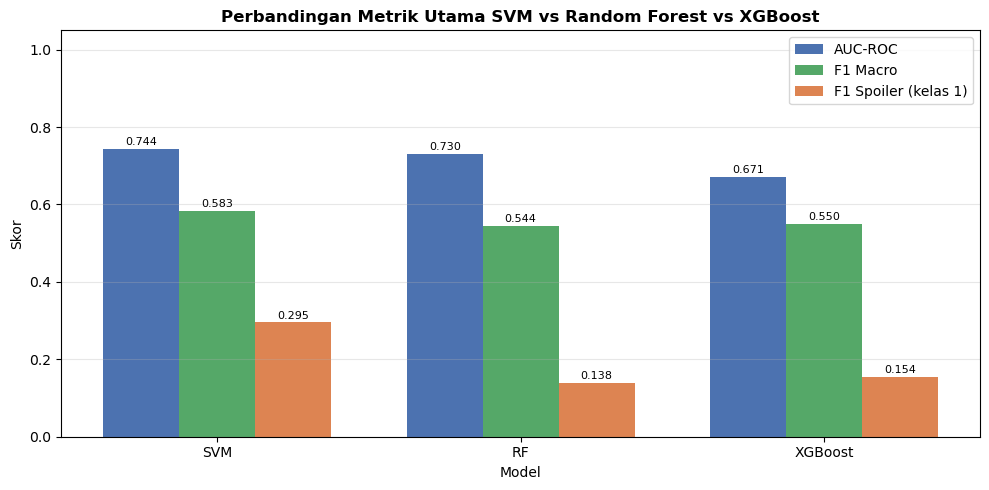

In [22]:
# visualisasi 1: bar chart perbandingan metrik utama
model_names = list(results.keys())
auc_values = [results[m]["auc_roc"] for m in model_names] # AUC-ROC setiap model
f1_macro = [results[m]["f1_macro"] for m in model_names] # F1 Macro setiap model
f1_spoiler = [results[m]["f1_1"] for m in model_names] # F1 kelas spoiler setiap model

x = np.arange(len(model_names)) # posisi x untuk setiap model
width = 0.25 # lebar setiap bar

fig, ax = plt.subplots(figsize=(10, 5))
# buat tiga kelompok bar side-by-side untuk tiga metrik
bars1 = ax.bar(x - width, auc_values, width, label="AUC-ROC", color="#4C72B0")
bars2 = ax.bar(x, f1_macro, width, label="F1 Macro", color="#55A868")
bars3 = ax.bar(x + width, f1_spoiler, width, label="F1 Spoiler (kelas 1)", color="#DD8452")

ax.set_xlabel("Model")
ax.set_ylabel("Skor")
ax.set_title("Perbandingan Metrik Utama SVM vs Random Forest vs XGBoost", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# tambahkan nilai numerik di atas setiap bar
for bars in [bars1, bars2, bars3]:
  for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("perbandingan_metrik.png", dpi=150, bbox_inches="tight")
plt.show()

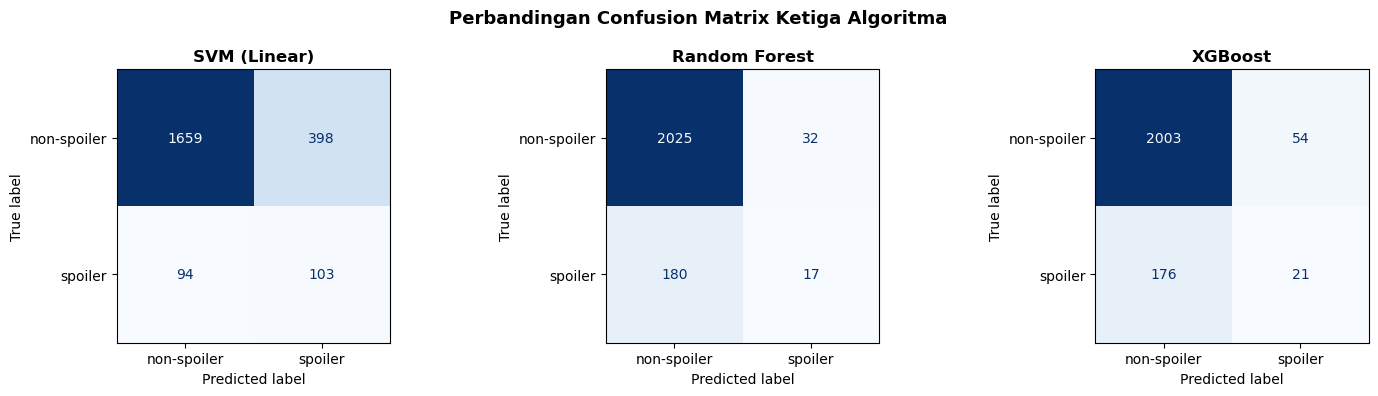


cara membaca confusion matrix:
- baris = label aktual (ground truth)
- kolom = label prediksi model

- atas kiri  (TN) : non-spoiler diprediksi non-spoiler -> benar
- atas kanan (FP) : non-spoiler diprediksi spoiler     -> salah (false alarm)
- bawah kiri (FN) : spoiler diprediksi non-spoiler     -> salah (spoiler lolos deteksi)
- bawah kanan(TP) : spoiler diprediksi spoiler         -> benar

untuk deteksi spoiler, FN (spoiler yang lolos) lebih berbahaya dari FP.
model dengan recall spoiler tinggi = lebih sedikit FN.



In [23]:
# visualisasi 2: confusion matrix ketiga model side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_pred_pairs = [
  ("SVM (Linear)", predictions["SVM"]),
  ("Random Forest", predictions["RF"]),
  ("XGBoost", predictions["XGBoost"]),
]

# plot confusion matrix setiap model ke subplot masing-masing
for ax, (name, pred) in zip(axes, model_pred_pairs):
  plot_confusion_matrix(name, y_test, pred, ax)

plt.suptitle("Perbandingan Confusion Matrix Ketiga Algoritma", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_all.png", dpi=150, bbox_inches="tight")
plt.show()

# penjelasan baca confusion matrix
print("""
cara membaca confusion matrix:
- baris = label aktual (ground truth)
- kolom = label prediksi model

- atas kiri  (TN) : non-spoiler diprediksi non-spoiler -> benar
- atas kanan (FP) : non-spoiler diprediksi spoiler     -> salah (false alarm)
- bawah kiri (FN) : spoiler diprediksi non-spoiler     -> salah (spoiler lolos deteksi)
- bawah kanan(TP) : spoiler diprediksi spoiler         -> benar

untuk deteksi spoiler, FN (spoiler yang lolos) lebih berbahaya dari FP.
model dengan recall spoiler tinggi = lebih sedikit FN.
""")

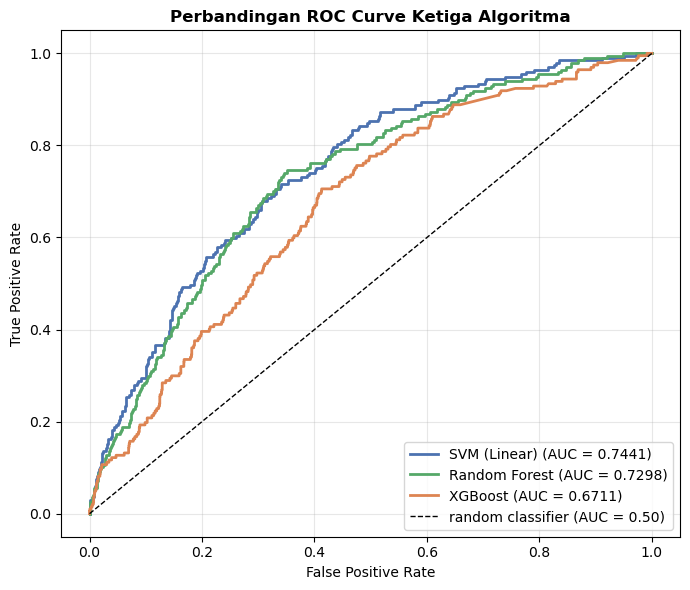

"\ncara membaca ROC curve:\n- sumbu x (FPR): proporsi non-spoiler yang salah diprediksi spoiler\n- sumbu y (TPR): proporsi spoiler yang berhasil terdeteksi (= recall kelas 1)\n- semakin kurva 'mendekati pojok kiri atas', semakin baik model\n- garis putus-putus = random classifier (tidak berguna sama sekali)\n- AUC = luas di bawah kurva. semakin mendekati 1.0, semakin baik\n"

In [25]:
# visualisasi 3: ROC curve ketiga model
from sklearn.metrics import roc_curve

# kumpulkan skor probabilitas/decision function semua model
all_scores = {
  "SVM (Linear)"  : best_svm.decision_function(X_test_raw), # jarak ke hyperplane
  "Random Forest" : best_rf.predict_proba(X_test_raw)[:, 1], # probabilitas kelas spoiler
  "XGBoost"       : best_xgb.predict_proba(X_test_raw)[:, 1],
}

fig, ax = plt.subplots(figsize=(7, 6))
colors_roc = ["#4C72B0", "#55A868", "#DD8452"]

for (name, score), color in zip(all_scores.items(), colors_roc):
  # hitung fpr dan tpr di semua threshold yang mungkin
  fpr, tpr, _ = roc_curve(y_test, score)
  auc = roc_auc_score(y_test, score)
  # plot kurva ROC untuk model ini
  ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", color=color, lw=2)

# tambahkan garis diagonal sebagai baseline random classifier
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random classifier (AUC = 0.50)")

ax.set_xlabel("False Positive Rate") # proporsi non-spoiler yang salah diprediksi spoiler
ax.set_ylabel("True Positive Rate")  # proporsi spoiler yang berhasil terdeteksi
ax.set_title("Perbandingan ROC Curve Ketiga Algoritma", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curve_all.png", dpi=150, bbox_inches="tight")
plt.show()

"""
cara membaca ROC curve:
- sumbu x (FPR): proporsi non-spoiler yang salah diprediksi spoiler
- sumbu y (TPR): proporsi spoiler yang berhasil terdeteksi (= recall kelas 1)
- semakin kurva 'mendekati pojok kiri atas', semakin baik model
- garis putus-putus = random classifier (tidak berguna sama sekali)
- AUC = luas di bawah kurva. semakin mendekati 1.0, semakin baik
"""

## 9. Kesimpulan dan Analisis

In [26]:
# model terbaik untuk setiap metrik
best_auc_model = max(results, key=lambda m: results[m]["auc_roc"]) # model dengan AUC tertinggi
best_f1_model = max(results, key=lambda m: results[m]["f1_1"]) # model dengan F1 spoiler tertinggi
best_rec_model = max(results, key=lambda m: results[m]["recall_1"]) # model dengan recall spoiler tertinggi

print("RINGKASAN HASIL")
print(f"\nalgoritma terbaik berdasarkan AUC-ROC: {best_auc_model} ({results[best_auc_model]['auc_roc']:.4f})")
print(f"algoritma terbaik berdasarkan F1 spoiler: {best_f1_model} ({results[best_f1_model]['f1_1']:.4f})")
print(f"algoritma terbaik berdasarkan recall spoiler: {best_rec_model} ({results[best_rec_model]['recall_1']:.4f})")

print("\nperbandingan final")
for model, r in results.items():
  print(f"\n{model}:")
  print(f"AUC-ROC         : {r['auc_roc']:.4f}")
  print(f"F1 spoiler      : {r['f1_1']:.4f}")
  print(f"Recall spoiler  : {r['recall_1']:.4f}")
  print(f"F1 macro        : {r['f1_macro']:.4f}")

RINGKASAN HASIL

algoritma terbaik berdasarkan AUC-ROC: SVM (0.7441)
algoritma terbaik berdasarkan F1 spoiler: SVM (0.2951)
algoritma terbaik berdasarkan recall spoiler: SVM (0.5228)

perbandingan final

SVM:
AUC-ROC         : 0.7441
F1 spoiler      : 0.2951
Recall spoiler  : 0.5228
F1 macro        : 0.5830

RF:
AUC-ROC         : 0.7298
F1 spoiler      : 0.1382
Recall spoiler  : 0.0863
F1 macro        : 0.5442

XGBoost:
AUC-ROC         : 0.6711
F1 spoiler      : 0.1544
Recall spoiler  : 0.1066
F1 macro        : 0.5501


Catatan Perubahan

**Mengapa Pipeline menggantikan TF-IDF standalone**  
TF-IDF yang di-fit di luar GridSearchCV menyebabkan data leakage: vocabulary terbentuk dari seluruh data latih sebelum cross-validation dimulai, sehingga setiap fold validasi sudah "terpengaruh" oleh distribusi kata dari fold training lainnya. Dengan Pipeline, TF-IDF di-fit ulang hanya pada data training di setiap fold, membuat evaluasi cross-validation menjadi valid.

**Handling imbalance dengan `class_weight='balanced'` dan `scale_pos_weight`**  
Pendekatan ini dipilih karena bekerja langsung pada fungsi loss tanpa mengubah distribusi data. SMOTE tidak dipakai karena interpolasi di ruang TF-IDF sparse tidak menghasilkan representasi teks yang bermakna secara linguistik. `scale_pos_weight` pada XGBoost sekarang ikut di-tune karena nilai optimal tidak selalu persis sama dengan rasio imbalance data.

**Keterbatasan**  
Model berbasis TF-IDF tidak memahami urutan kata. Kosakata yang sangat mirip antar kelas menjadi pembatas fundamental untuk semua model ML klasik, dan ini yang membuka motivasi untuk pendekatan deep learning dan BERT.

In [ ]:
'''
import os, joblib

EXPORT_DIR = "/content/drive/MyDrive/NLP_Kelompok3/models_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

joblib.dump(vectorizer, os.path.join(EXPORT_DIR, "vectorizer.pkl"))
print("vectorizer.pkl tersimpan")

joblib.dump(best_svm, os.path.join(EXPORT_DIR, "svm_model.pkl"))
print("svm_model.pkl tersimpan")

joblib.dump(best_rf, os.path.join(EXPORT_DIR, "rf_model.pkl"))
print("rf_model.pkl tersimpan")

joblib.dump(best_xgb, os.path.join(EXPORT_DIR, "xgb_model.pkl"))
print("xgb_model.pkl tersimpan")
'''